In [ ]:
pip install imbalanced-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier


In [296]:
df = pd.read_csv("/content/Test.csv")
print(df)

          ID  Gender Ever_Married  Age Graduated     Profession  \
0     458989  Female          Yes   36       Yes       Engineer   
1     458994    Male          Yes   37       Yes     Healthcare   
2     458996  Female          Yes   69        No            NaN   
3     459000    Male          Yes   59        No      Executive   
4     459001  Female           No   19        No      Marketing   
...      ...     ...          ...  ...       ...            ...   
2622  467954    Male           No   29        No     Healthcare   
2623  467958  Female           No   35       Yes         Doctor   
2624  467960  Female           No   53       Yes  Entertainment   
2625  467961    Male          Yes   47       Yes      Executive   
2626  467968  Female           No   43       Yes     Healthcare   

      Work_Experience Spending_Score  Family_Size  Var_1  
0                 0.0            Low          1.0  Cat_6  
1                 8.0        Average          4.0  Cat_6  
2                 

In [297]:
df2 = pd.read_csv("/content/Train.csv")
print(df2)

          ID  Gender Ever_Married  Age Graduated     Profession  \
0     462809    Male           No   22        No     Healthcare   
1     462643  Female          Yes   38       Yes       Engineer   
2     466315  Female          Yes   67       Yes       Engineer   
3     461735    Male          Yes   67       Yes         Lawyer   
4     462669  Female          Yes   40       Yes  Entertainment   
...      ...     ...          ...  ...       ...            ...   
8063  464018    Male           No   22        No            NaN   
8064  464685    Male           No   35        No      Executive   
8065  465406  Female           No   33       Yes     Healthcare   
8066  467299  Female           No   27       Yes     Healthcare   
8067  461879    Male          Yes   37       Yes      Executive   

      Work_Experience Spending_Score  Family_Size  Var_1 Segmentation  
0                 1.0            Low          4.0  Cat_4            D  
1                 NaN        Average          3.0  

In [298]:
df.update(df2)
print(df)

          ID  Gender Ever_Married  Age Graduated     Profession  \
0     462809    Male           No   22        No     Healthcare   
1     462643  Female          Yes   38       Yes       Engineer   
2     466315  Female          Yes   67       Yes       Engineer   
3     461735    Male          Yes   67       Yes         Lawyer   
4     462669  Female          Yes   40       Yes  Entertainment   
...      ...     ...          ...  ...       ...            ...   
2622  463124    Male          Yes   31        No         Artist   
2623  461463    Male           No   41       Yes         Artist   
2624  464566    Male          Yes   35       Yes      Executive   
2625  462070    Male          Yes   41       Yes  Entertainment   
2626  464162    Male          Yes   81       Yes         Lawyer   

      Work_Experience Spending_Score  Family_Size  Var_1  
0                 1.0            Low          4.0  Cat_4  
1                 8.0        Average          3.0  Cat_4  
2                 

In [299]:
for col_name in df.columns:
  print(f"{col_name} : {df[col_name].dtype}")

ID : int64
Gender : object
Ever_Married : object
Age : int64
Graduated : object
Profession : object
Work_Experience : float64
Spending_Score : object
Family_Size : float64
Var_1 : object


In [300]:
le = LabelEncoder()
scaler = StandardScaler()

df["Var_1"] = df["Var_1"].apply(lambda x:1 if x == "Cat_6" else 0)

for col in df:
  if df[col].dtype == "object" and col != "Var_1":
    df[col] = le.fit_transform(df[col].astype(str))

print(df)

# df.drop('ID', axis = 1, inplace=True)


y = df['Var_1']
x = df.drop(['Var_1'], axis=1)

for col in x:
  if x[col].isnull().sum() > 0 and x[col].dtype != "object":
    x.fillna(x[col].mean(), inplace=True)
  else:
    imputer = SimpleImputer(strategy="most_frequent")
    df[col] = imputer.fit_transform(df[[col]]).ravel()




          ID  Gender  Ever_Married  Age  Graduated  Profession  \
0     462809       1             0   22          0           5   
1     462643       0             1   38          1           2   
2     466315       0             1   67          1           2   
3     461735       1             1   67          1           7   
4     462669       0             1   40          1           3   
...      ...     ...           ...  ...        ...         ...   
2622  463124       1             1   31          0           0   
2623  461463       1             0   41          1           0   
2624  464566       1             1   35          1           4   
2625  462070       1             1   41          1           3   
2626  464162       1             1   81          1           7   

      Work_Experience  Spending_Score  Family_Size  Var_1  
0                 1.0               2          4.0      0  
1                 8.0               0          3.0      0  
2                 1.0      

In [301]:
y.dtype

dtype('int64')

In [302]:
y

,Var_1
0,0
1,0
2,1
3,1
4,1
...,...
2622,1
2623,0
2624,1
2625,1


In [303]:
y.value_counts()

,count
Var_1,
1,1751
0,876


In [304]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

print("Original y_train value counts:")
print(y.value_counts())
print("\nResampled y_train value counts (after SMOTE):")
print(y_resampled.value_counts())

Original y_train value counts:
Var_1
1    1751
0     876
Name: count, dtype: int64

Resampled y_train value counts (after SMOTE):
Var_1
0    1751
1    1751
Name: count, dtype: int64


In [305]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.2, random_state=42)

In [306]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2801, 9)
(701, 9)
(2801,)
(701,)


In [307]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

xgb_model = XGBClassifier(
   n_estimators=300,
    learning_rate=0.1,
    max_depth=5,

    random_state=42,
    n_jobs=-1,

    colsample_bytree=0.7,
    subsample=0.8,

    objective='binary:logistic'
    # tree_method='auto'
   )

xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)

accuracy_scores = accuracy_score(y_test, y_pred)
precision_scores = precision_score(y_test, y_pred)
recall_scores = recall_score(y_test, y_pred)
f1_scores = f1_score(y_test, y_pred) # caluculate metrics considering class imbalance

print(f"""
Accuracy Score : {accuracy_scores}
Precision Score : {precision_scores}
Recall Score : {recall_scores}
F1 Score : {f1_scores} """)

# r2_score = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"R2 Score: {r2_score}")
# print(f"Mean Absolute Error: {mae}")
# print(f"Mean Squared Error: {mse}")


Accuracy Score : 0.7788873038516405
Precision Score : 0.7506361323155216
Recall Score : 0.8380681818181818
F1 Score : 0.7919463087248322 


In [308]:
y_train.value_counts()

,count
Var_1,
0,1402
1,1399


In [309]:
y_test.value_counts()

,count
Var_1,
1,352
0,349


              precision    recall  f1-score   support

           0       0.81      0.72      0.76       349
           1       0.75      0.84      0.79       352

    accuracy                           0.78       701
   macro avg       0.78      0.78      0.78       701
weighted avg       0.78      0.78      0.78       701



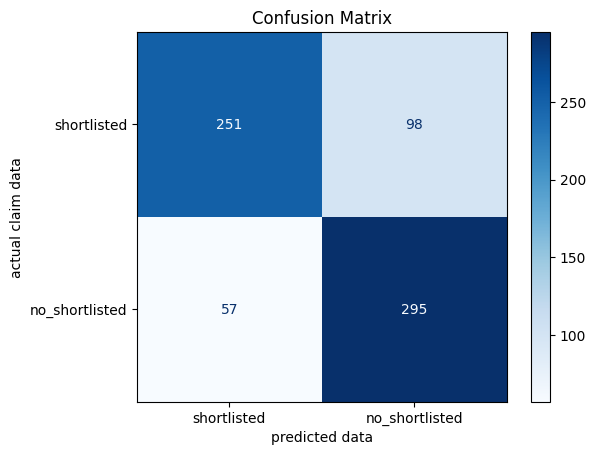

In [310]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['shortlisted', 'no_shortlisted']) # Assuming binary classification for 'liked'
disp.plot(cmap=plt.cm.Blues)

plt.xlabel('predicted data')
plt.ylabel('actual claim data')
plt.title('Confusion Matrix')
plt.show()

In [311]:
import joblib
if joblib.dump(xgb_model, 'customer_segmentation.pkl'):
  print("model saved")

model saved
